# Model Evaluation & Comparison

Notebook này đánh giá và so sánh các model trên cùng tập dữ liệu đã chia (train/val/test),
với cả raw features và engineered features.

**Các model được đánh giá:**
1. Linear Regression — Raw (5 features)
2. Linear Regression — Engineered (9 features)
3. Random Forest Default — Raw (5 features)
4. Random Forest Tuned — Raw (5 features)
5. Random Forest Default — Engineered (9 features)

**Metric:** MSE, MAE, R²

**Phân tích bổ sung:**
- So sánh metric giữa các model
- Residual analysis (phân phối sai số)
- Feature importance
- Vấn đề mà model mới / engineered features khắc phục

---
## 1. Setup & Load Data

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

# ---------- path setup ----------
ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from configs import data_config as cfg
from src.process_data.engineering import (
    add_engineered_features,
    build_preprocessor,
    select_base_features,
)

# ---------- plot style ----------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


In [2]:
# ---------- load pre-split data ----------
data_dir = cfg.processed_dir

X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(data_dir, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(data_dir, "X_test.csv"))

y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).squeeze()
y_val   = pd.read_csv(os.path.join(data_dir, "y_val.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(data_dir, "y_test.csv")).squeeze()

print(f"Train : {len(X_train):>6} rows")
print(f"Val   : {len(X_val):>6} rows")
print(f"Test  : {len(X_test):>6} rows")
print(f"Total : {len(X_train)+len(X_val)+len(X_test):>6} rows")
print(f"\nFeature columns: {X_train.columns.tolist()}")
print(f"Target: {y_train.name}")

Train :  35000 rows
Val   :   7500 rows
Test  :   7500 rows
Total :  50000 rows

Feature columns: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Burnout_Risk_Level']
Target: Post_Semester_GPA


---
## 2. Chuẩn bị Feature Sets

- **Raw features (5):** Pre_Semester_GPA, Weekly_GenAI_Hours, Tool_Diversity, Paid_Subscription, Perceived_AI_Dependency
- **Engineered features (9):** Raw + Weekly_GenAI_Hours_Sq, PreGPA_Sq, PreGPA_x_Tool, AI_Engagement_Index

In [3]:
base_features = cfg.features
engineered_only = [
    "Weekly_GenAI_Hours_Sq",
    "PreGPA_Sq",
    "PreGPA_x_Tool",
    "AI_Engagement_Index",
]
all_features = base_features + engineered_only

# --- Raw feature sets ---
X_train_raw = select_base_features(X_train)
X_val_raw   = select_base_features(X_val)
X_test_raw  = select_base_features(X_test)

# --- Engineered feature sets ---
X_train_eng, means = add_engineered_features(X_train)
X_val_eng, _       = add_engineered_features(X_val, means=means)
X_test_eng, _      = add_engineered_features(X_test, means=means)

print("Raw features:", base_features)
print("\nEngineered features (added):", engineered_only)
print("\nCentering means (from train):")
for k, v in means.items():
    print(f"  {k}: {v:.4f}")

Raw features: ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Paid_Subscription', 'Perceived_AI_Dependency']

Engineered features (added): ['Weekly_GenAI_Hours_Sq', 'PreGPA_Sq', 'PreGPA_x_Tool', 'AI_Engagement_Index']

Centering means (from train):
  Weekly_GenAI_Hours: 8.4072
  Tool_Diversity: 2.8034
  Pre_Semester_GPA: 3.1478


---
## 3. Hàm hỗ trợ

In [4]:
def compute_metrics(y_true, y_pred):
    """Tính MSE, MAE, R² — bộ metric thống nhất cho tất cả model."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R²":  r2_score(y_true, y_pred),
    }

# Container to store all results
results = {}   # key: model name  ->  {"model": ..., "train": {...}, "val": {...}, "test": {...}, "predictions": {...}}

def store_result(name, model, y_train, y_val, y_test, pred_train, pred_val, pred_test):
    results[name] = {
        "model": model,
        "train": compute_metrics(y_train, pred_train),
        "val":   compute_metrics(y_val,   pred_val),
        "test":  compute_metrics(y_test,  pred_test),
        "predictions": {
            "train": pred_train,
            "val":   pred_val,
            "test":  pred_test,
        },
    }


---
## 4. Linear Regression

### 4.1 Linear Regression — Raw Features (5)

In [5]:
lr_raw = LinearRegression()
lr_raw.fit(X_train_raw, y_train)

pred_train = lr_raw.predict(X_train_raw)
pred_val   = lr_raw.predict(X_val_raw)
pred_test  = lr_raw.predict(X_test_raw)

store_result("LR Raw (5)", lr_raw, y_train, y_val, y_test, pred_train, pred_val, pred_test)

print("Linear Regression — Raw Features")
for split in ("train", "val", "test"):
    m = results["LR Raw (5)"][split]
    print(f"  {split:6s}  |  MSE: {m['MSE']:.6f}  MAE: {m['MAE']:.6f}  R²: {m['R²']:.6f}")

print("\nCoefficients:")
for feat, coef in zip(base_features, lr_raw.coef_):
    print(f"  {feat:30s}: {coef:+.6f}")
print(f"  {'Intercept':30s}: {lr_raw.intercept_:+.6f}")

Linear Regression — Raw Features
  train   |  MSE: 0.033941  MAE: 0.143549  R²: 0.860307
  val     |  MSE: 0.035332  MAE: 0.146821  R²: 0.859504
  test    |  MSE: 0.035145  MAE: 0.145476  R²: 0.860791

Coefficients:
  Pre_Semester_GPA              : +0.957196
  Weekly_GenAI_Hours            : -0.000829
  Tool_Diversity                : +0.012050
  Paid_Subscription             : +0.010605
  Perceived_AI_Dependency       : -0.001021
  Intercept                     : +0.310717


### 4.2 Linear Regression — Engineered Features (9)

In [6]:
lr_eng = LinearRegression()
lr_eng.fit(X_train_eng[all_features], y_train)

pred_train = lr_eng.predict(X_train_eng[all_features])
pred_val   = lr_eng.predict(X_val_eng[all_features])
pred_test  = lr_eng.predict(X_test_eng[all_features])

store_result("LR Eng (9)", lr_eng, y_train, y_val, y_test, pred_train, pred_val, pred_test)

print("Linear Regression — Engineered Features")
for split in ("train", "val", "test"):
    m = results["LR Eng (9)"][split]
    print(f"  {split:6s}  |  MSE: {m['MSE']:.6f}  MAE: {m['MAE']:.6f}  R²: {m['R²']:.6f}")

print("\nCoefficients:")
for feat, coef in zip(all_features, lr_eng.coef_):
    print(f"  {feat:30s}: {coef:+.6f}")
print(f"  {'Intercept':30s}: {lr_eng.intercept_:+.6f}")

Linear Regression — Engineered Features
  train   |  MSE: 0.033262  MAE: 0.142114  R²: 0.863104
  val     |  MSE: 0.034619  MAE: 0.145656  R²: 0.862338
  test    |  MSE: 0.034390  MAE: 0.143847  R²: 0.863784

Coefficients:
  Pre_Semester_GPA              : +0.936800
  Weekly_GenAI_Hours            : +0.001407
  Tool_Diversity                : +0.012138
  Paid_Subscription             : +0.008971
  Perceived_AI_Dependency       : -0.000655
  Weekly_GenAI_Hours_Sq         : -0.000170
  PreGPA_Sq                     : -0.071088
  PreGPA_x_Tool                 : -0.005342
  AI_Engagement_Index           : +0.000186
  Intercept                     : +0.383072


---
## 5. Random Forest

### 5.1 Random Forest Default — Raw Features

In [7]:
# Preprocessing: scale raw features
preprocessor_raw = build_preprocessor(use_engineered=False)
X_train_raw_sc = preprocessor_raw.fit_transform(X_train_raw)
X_val_raw_sc   = preprocessor_raw.transform(X_val_raw)
X_test_raw_sc  = preprocessor_raw.transform(X_test_raw)

rf_raw = RandomForestRegressor(
    n_estimators=300,
    random_state=cfg.random_state,
    n_jobs=-1,
)
rf_raw.fit(X_train_raw_sc, y_train)

pred_train = rf_raw.predict(X_train_raw_sc)
pred_val   = rf_raw.predict(X_val_raw_sc)
pred_test  = rf_raw.predict(X_test_raw_sc)

store_result("RF Raw Default", rf_raw, y_train, y_val, y_test, pred_train, pred_val, pred_test)

print("Random Forest Default — Raw Features")
for split in ("train", "val", "test"):
    m = results["RF Raw Default"][split]
    print(f"  {split:6s}  |  MSE: {m['MSE']:.6f}  MAE: {m['MAE']:.6f}  R²: {m['R²']:.6f}")

Random Forest Default — Raw Features
  train   |  MSE: 0.005040  MAE: 0.055063  R²: 0.979256
  val     |  MSE: 0.038041  MAE: 0.152064  R²: 0.848731
  test    |  MSE: 0.037327  MAE: 0.149581  R²: 0.852147


### 5.2 Random Forest Tuned — Raw Features (RandomizedSearchCV)

In [8]:
PARAM_DISTRIBUTIONS = {
    "n_estimators":     [100, 200, 300, 400, 500],
    "max_depth":        [5, 10, 15, 20, 30, None],
    "min_samples_leaf": [1, 2, 4, 8, 16],
    "max_features":     ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
}

search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=cfg.random_state, n_jobs=-1),
    param_distributions=PARAM_DISTRIBUTIONS,
    n_iter=30,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=cfg.random_state,
    n_jobs=1,
    verbose=1,
)
search.fit(X_train_raw_sc, y_train)

rf_tuned = search.best_estimator_

pred_train = rf_tuned.predict(X_train_raw_sc)
pred_val   = rf_tuned.predict(X_val_raw_sc)
pred_test  = rf_tuned.predict(X_test_raw_sc)

store_result("RF Raw Tuned", rf_tuned, y_train, y_val, y_test, pred_train, pred_val, pred_test)

print("\nRandom Forest Tuned — Raw Features")
for split in ("train", "val", "test"):
    m = results["RF Raw Tuned"][split]
    print(f"  {split:6s}  |  MSE: {m['MSE']:.6f}  MAE: {m['MAE']:.6f}  R²: {m['R²']:.6f}")

print("\nBest hyper-parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Random Forest Tuned — Raw Features
  train   |  MSE: 0.029626  MAE: 0.133966  R²: 0.878067
  val     |  MSE: 0.034809  MAE: 0.145593  R²: 0.861584
  test    |  MSE: 0.034257  MAE: 0.143198  R²: 0.864309

Best hyper-parameters:
  n_estimators: 500
  min_samples_leaf: 16
  max_features: 1.0
  max_depth: 10


### 5.3 Random Forest Default — Engineered Features

In [9]:
# Preprocessing: scale engineered features
preprocessor_eng = build_preprocessor(use_engineered=True)
X_train_eng_sc = preprocessor_eng.fit_transform(X_train_eng)
X_val_eng_sc   = preprocessor_eng.transform(X_val_eng)
X_test_eng_sc  = preprocessor_eng.transform(X_test_eng)

rf_eng = RandomForestRegressor(
    n_estimators=300,
    random_state=cfg.random_state,
    n_jobs=-1,
)
rf_eng.fit(X_train_eng_sc, y_train)

pred_train = rf_eng.predict(X_train_eng_sc)
pred_val   = rf_eng.predict(X_val_eng_sc)
pred_test  = rf_eng.predict(X_test_eng_sc)

store_result("RF Eng Default", rf_eng, y_train, y_val, y_test, pred_train, pred_val, pred_test)

print("Random Forest Default — Engineered Features")
for split in ("train", "val", "test"):
    m = results["RF Eng Default"][split]
    print(f"  {split:6s}  |  MSE: {m['MSE']:.6f}  MAE: {m['MAE']:.6f}  R²: {m['R²']:.6f}")

Random Forest Default — Engineered Features
  train   |  MSE: 0.005077  MAE: 0.055197  R²: 0.979105
  val     |  MSE: 0.038027  MAE: 0.151973  R²: 0.848786
  test    |  MSE: 0.037464  MAE: 0.150157  R²: 0.851606


---
## 6. So sánh Metric giữa các Model

In [10]:
# Build comparison DataFrame
rows = []
for name, res in results.items():
    for split in ("train", "val", "test"):
        m = res[split]
        rows.append({
            "Model": name,
            "Split": split.capitalize(),
            "MSE": m["MSE"],
            "MAE": m["MAE"],
            "R²":  m["R²"],
        })

df_metrics = pd.DataFrame(rows)

# Show table
print("BẢNG SO SÁNH METRIC GIỮA CÁC MODEL")
display(df_metrics.style.format({"MSE": "{:.6f}", "MAE": "{:.6f}", "R²": "{:.6f}"}))

BẢNG SO SÁNH METRIC GIỮA CÁC MODEL


,Model,Split,MSE,MAE,R²
0,LR Raw (5),Train,0.033941,0.143549,0.860307
1,LR Raw (5),Val,0.035332,0.146821,0.859504
2,LR Raw (5),Test,0.035145,0.145476,0.860791
3,LR Eng (9),Train,0.033262,0.142114,0.863104
4,LR Eng (9),Val,0.034619,0.145656,0.862338
5,LR Eng (9),Test,0.034390,0.143847,0.863784
6,RF Raw Default,Train,0.005040,0.055063,0.979256
7,RF Raw Default,Val,0.038041,0.152064,0.848731
8,RF Raw Default,Test,0.037327,0.149581,0.852147
9,RF Raw Tuned,Train,0.029626,0.133966,0.878067


In [11]:
# Focus on TEST set metrics
df_test = df_metrics[df_metrics["Split"] == "Test"].copy()
df_test = df_test.set_index("Model").drop(columns="Split")

print("BẢNG SO SÁNH METRIC TRÊN TẬP TEST")
display(df_test.style
    .format({"MSE": "{:.6f}", "MAE": "{:.6f}", "R²": "{:.6f}"})
    .highlight_min(subset=["MSE", "MAE"], color="lightgreen")
    .highlight_max(subset=["R²"], color="lightgreen")
)

BẢNG SO SÁNH METRIC TRÊN TẬP TEST


,MSE,MAE,R²
Model,,,
LR Raw (5),0.035145,0.145476,0.860791
LR Eng (9),0.034390,0.143847,0.863784
RF Raw Default,0.037327,0.149581,0.852147
RF Raw Tuned,0.034257,0.143198,0.864309
RF Eng Default,0.037464,0.150157,0.851606


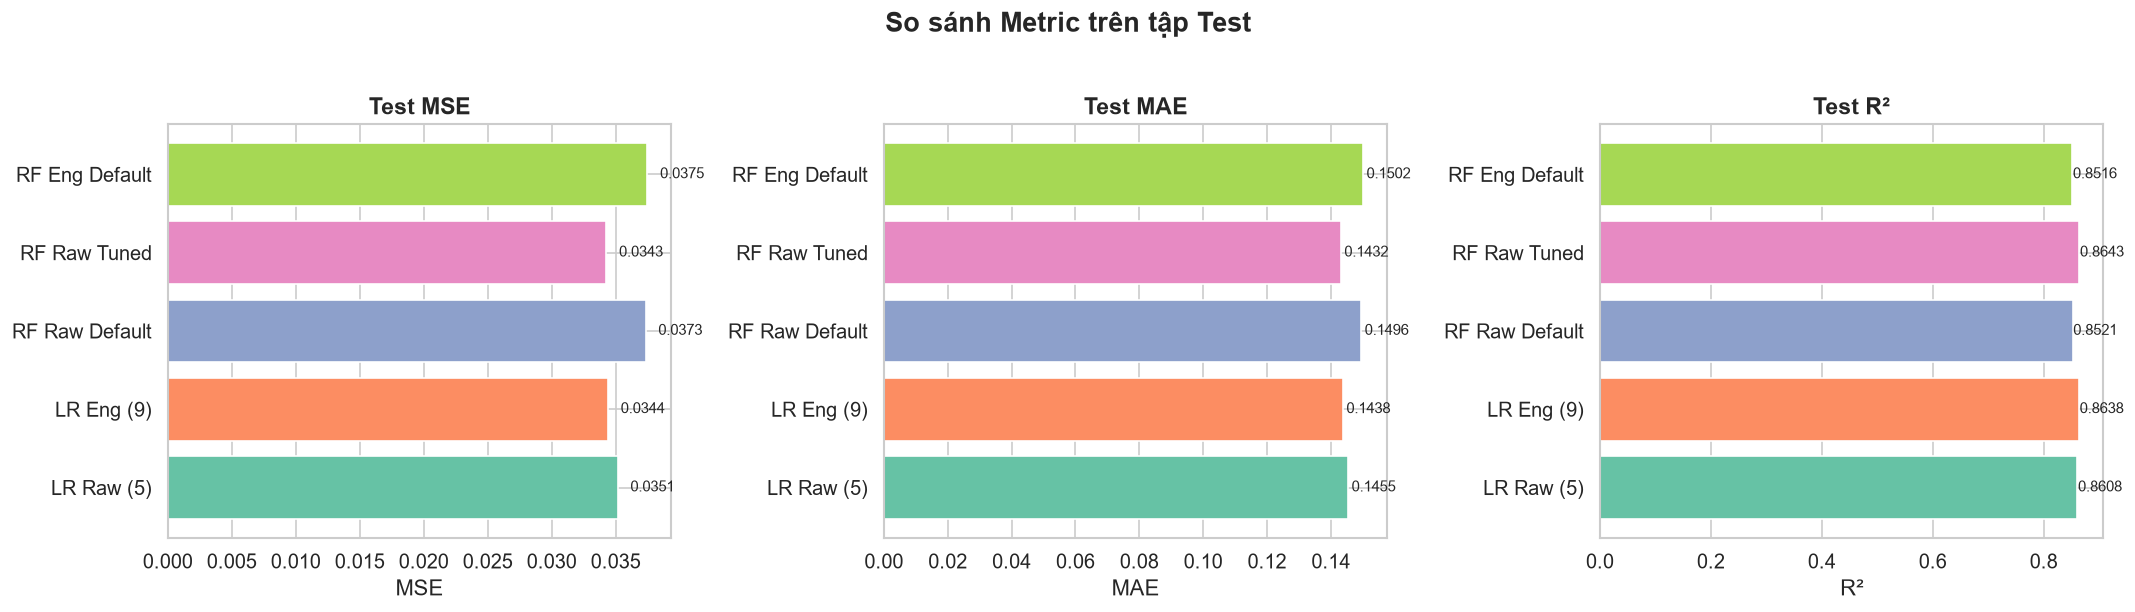

In [12]:
# Bar charts: MSE, MAE, R² on Test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(results.keys())
colors = sns.color_palette("Set2", len(model_names))

for ax, metric in zip(axes, ["MSE", "MAE", "R²"]):
    values = [results[name]["test"][metric] for name in model_names]
    bars = ax.barh(model_names, values, color=colors)
    ax.set_title(f"Test {metric}", fontsize=14, fontweight="bold")
    ax.set_xlabel(metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("So sánh Metric trên tập Test", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Phân tích Overfitting (Train vs Val vs Test)

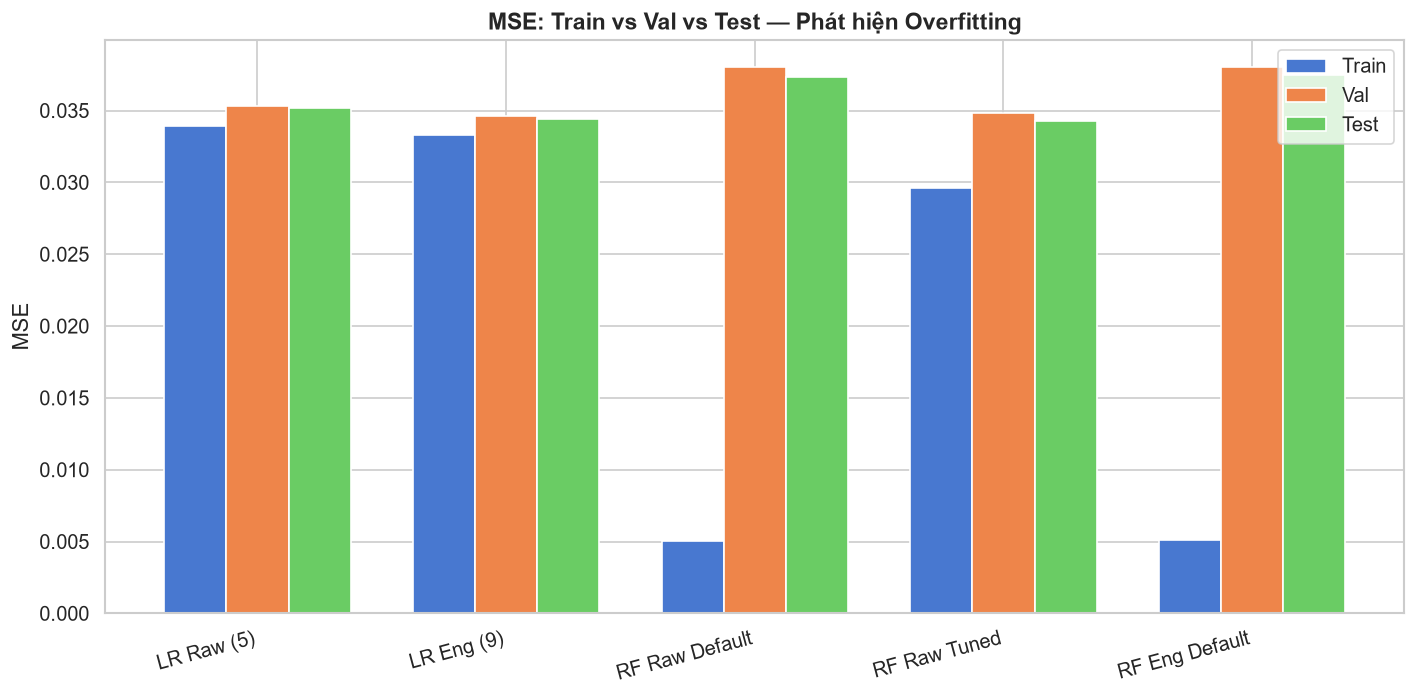


Overfitting Gap (Train MSE vs Test MSE):
  LR Raw (5)            |  Gap: +0.001204  |  Test/Train: 1.04x
  LR Eng (9)            |  Gap: +0.001128  |  Test/Train: 1.03x
  RF Raw Default        |  Gap: +0.032287  |  Test/Train: 7.41x
  RF Raw Tuned          |  Gap: +0.004631  |  Test/Train: 1.16x
  RF Eng Default        |  Gap: +0.032387  |  Test/Train: 7.38x


In [13]:
# Overfitting analysis: compare Train vs Val vs Test MSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.25

for i, split in enumerate(["train", "val", "test"]):
    values = [results[name][split]["MSE"] for name in model_names]
    ax.bar(x + i * width, values, width, label=split.capitalize())

ax.set_ylabel("MSE")
ax.set_title("MSE: Train vs Val vs Test — Phát hiện Overfitting", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# Print gap analysis
print("\nOverfitting Gap (Train MSE vs Test MSE):")
for name in model_names:
    train_mse = results[name]["train"]["MSE"]
    test_mse  = results[name]["test"]["MSE"]
    gap = test_mse - train_mse
    ratio = test_mse / train_mse if train_mse > 0 else float('inf')
    print(f"  {name:20s}  |  Gap: {gap:+.6f}  |  Test/Train: {ratio:.2f}x")

---
## 8. Residual Analysis (Phân tích sai số)

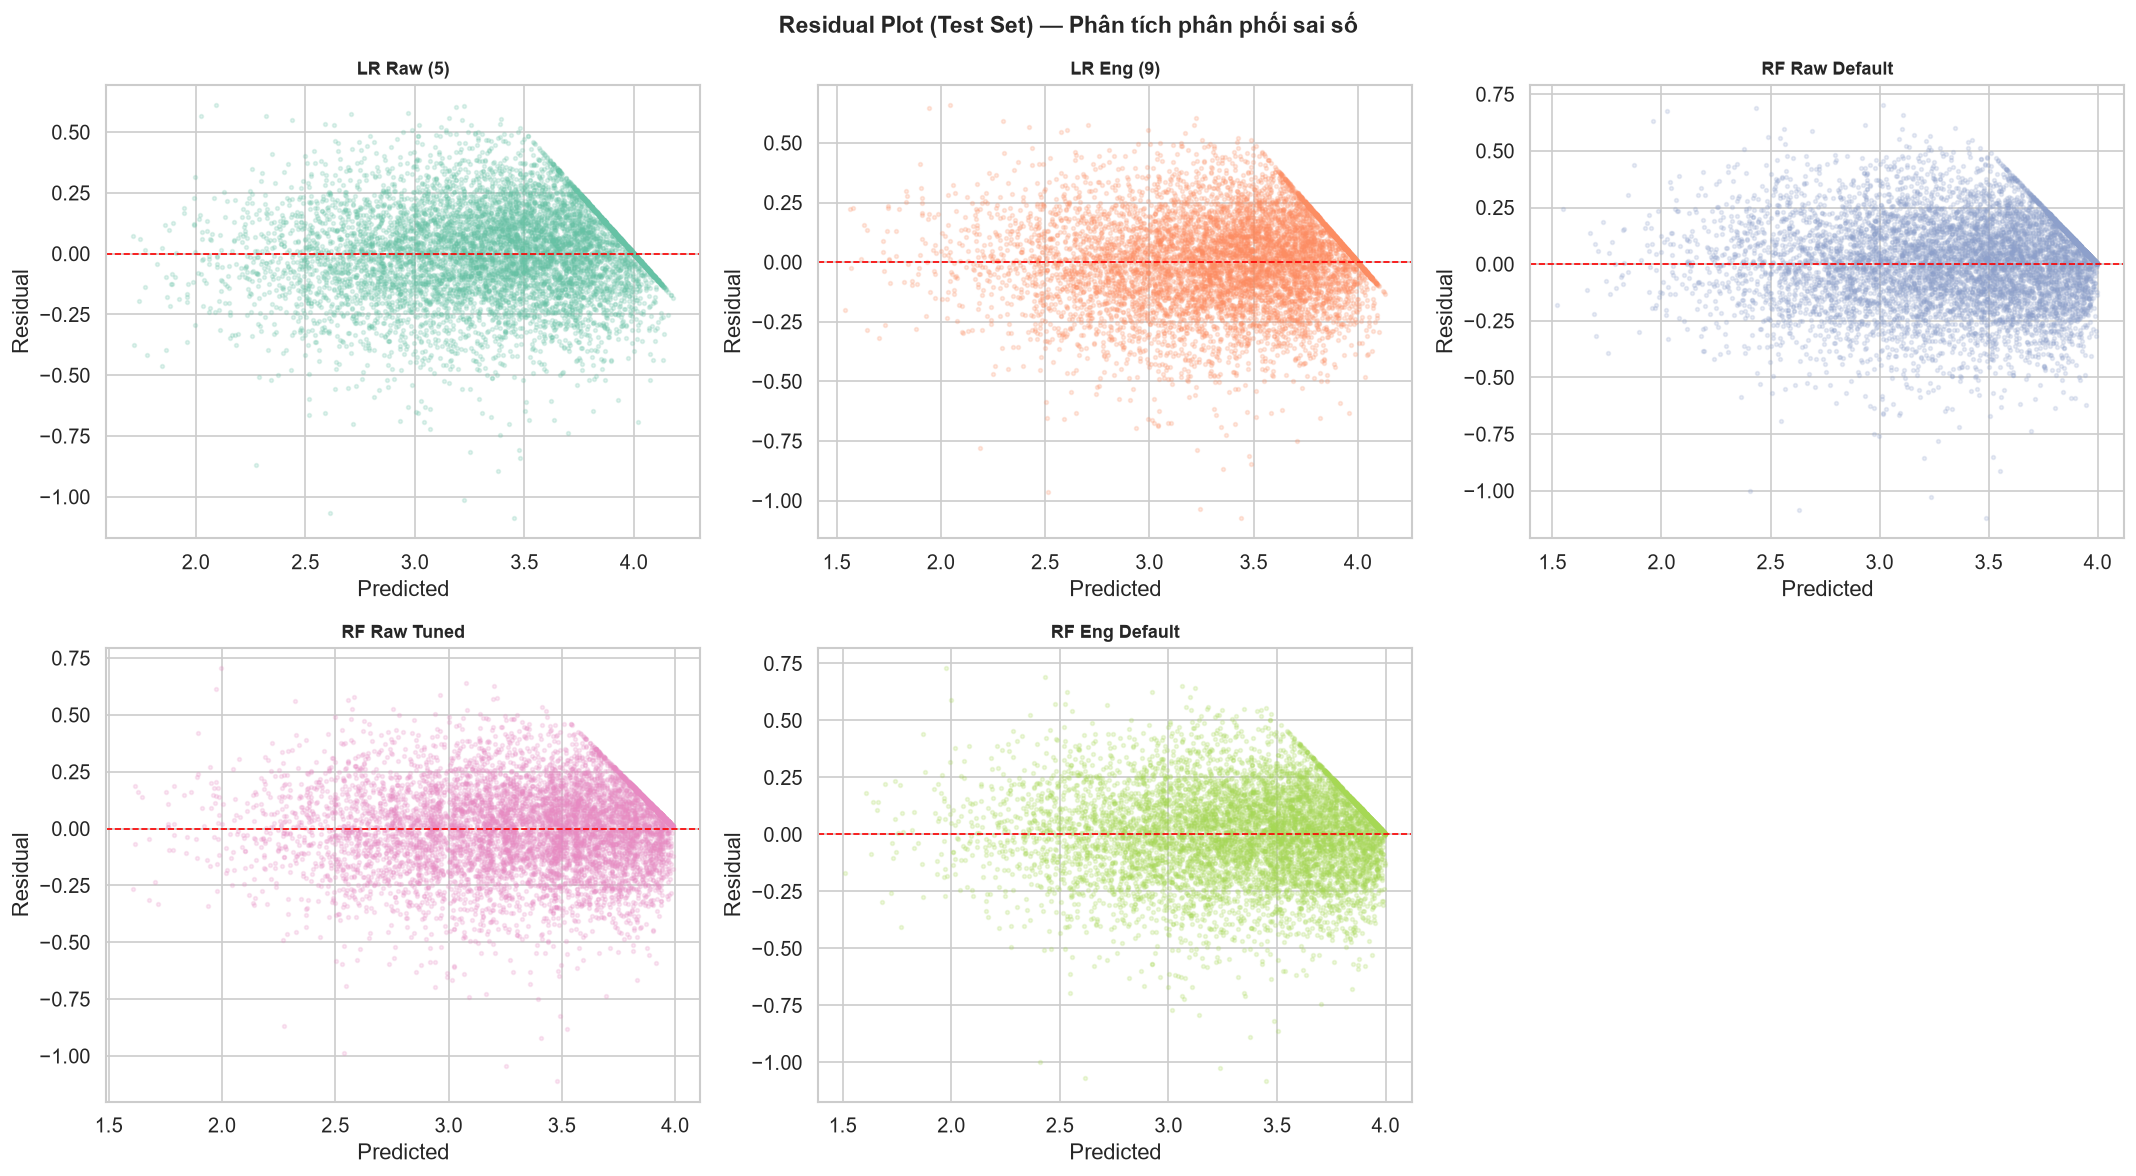

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, res) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    pred_test_vals = res["predictions"]["test"]
    residuals = y_test.values - pred_test_vals
    
    ax.scatter(pred_test_vals, residuals, alpha=0.2, s=5, color=colors[idx])
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

# Hide unused subplot
if len(results) < 6:
    for idx in range(len(results), 6):
        axes[idx // 3, idx % 3].set_visible(False)

plt.suptitle("Residual Plot (Test Set) — Phân tích phân phối sai số",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

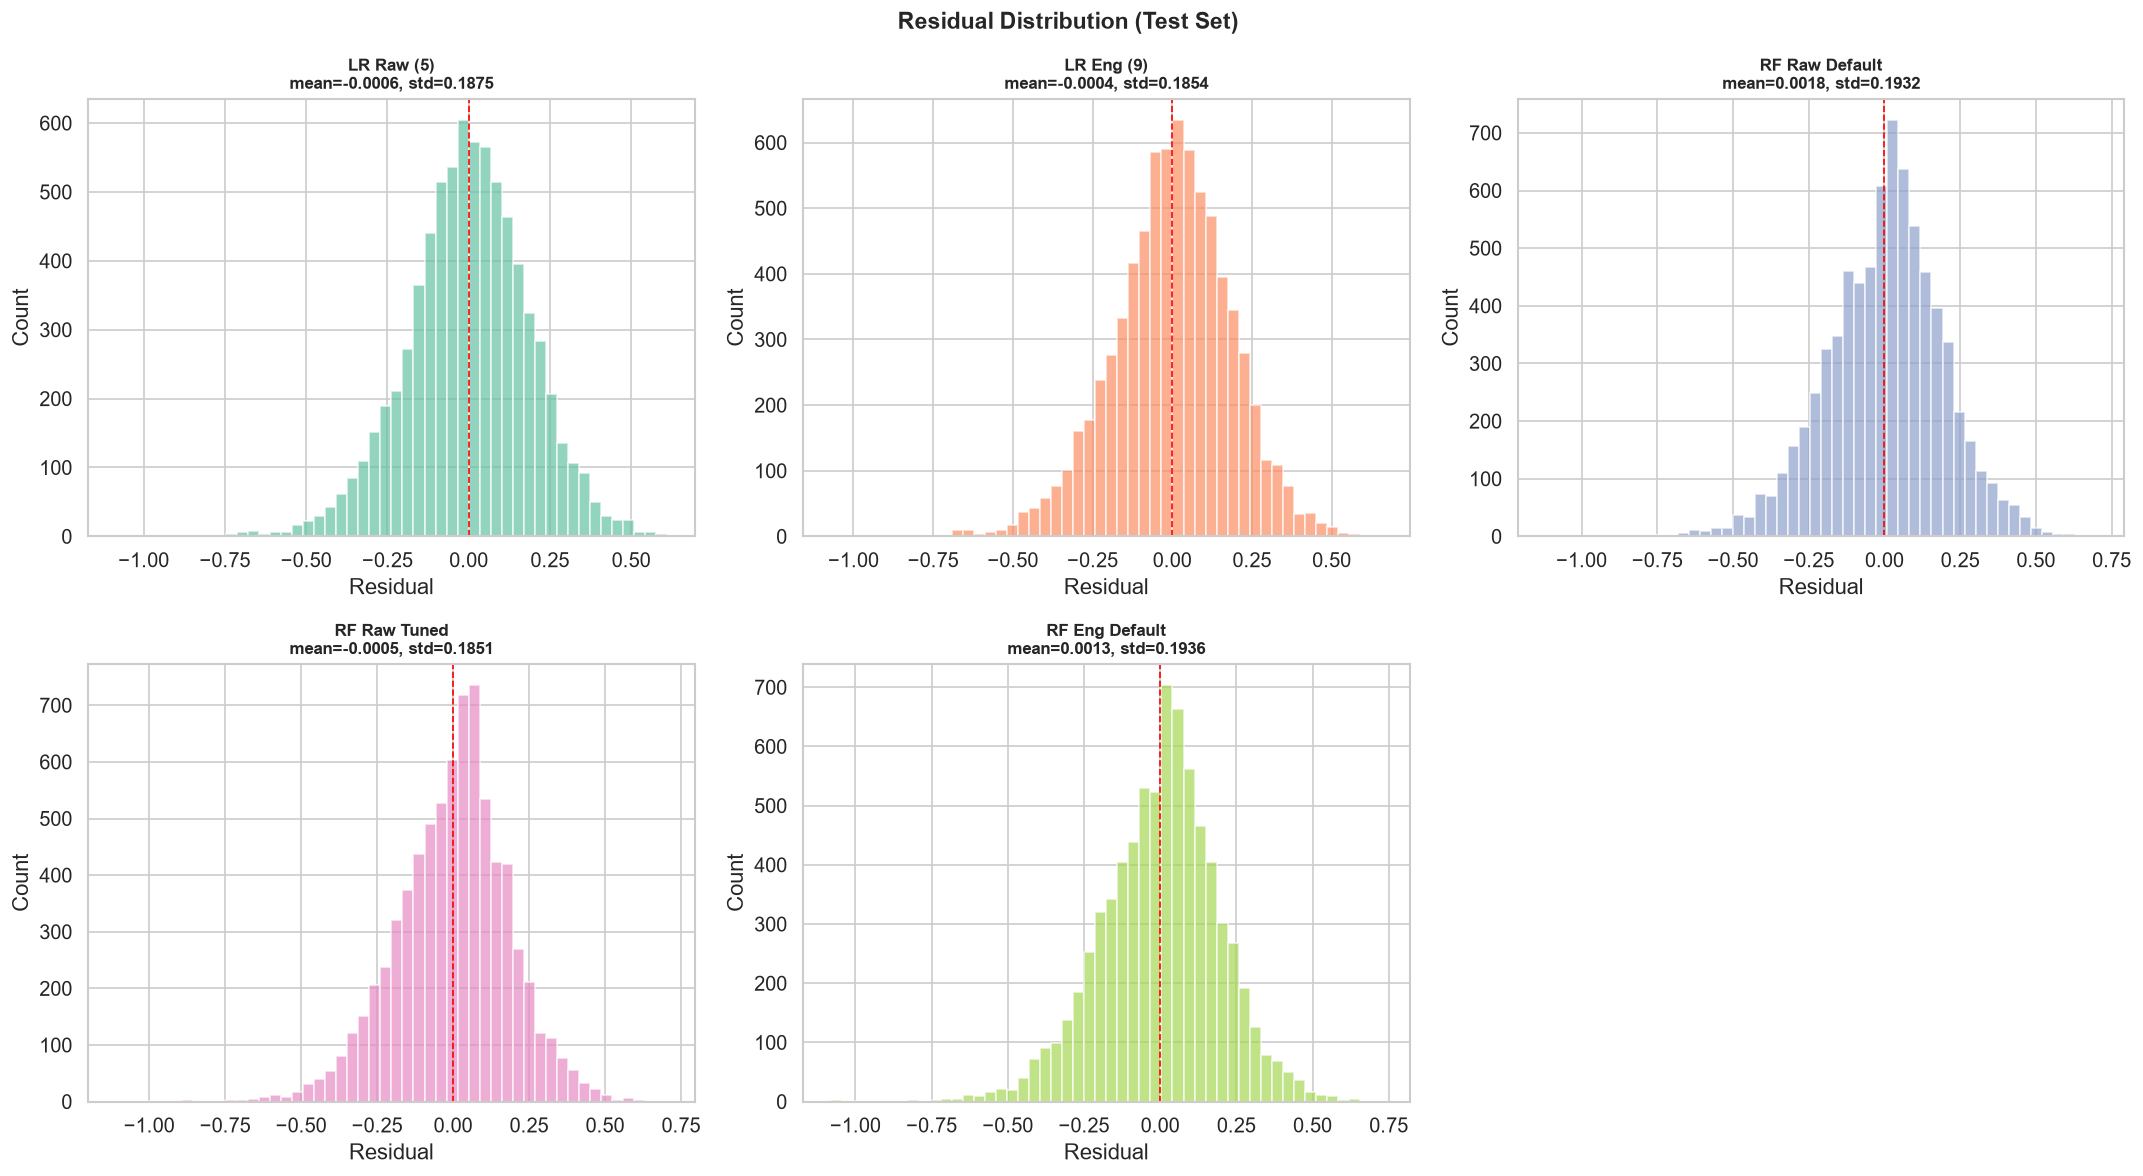

In [15]:
# Residual distribution (histogram)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, res) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    pred_test_vals = res["predictions"]["test"]
    residuals = y_test.values - pred_test_vals
    
    ax.hist(residuals, bins=50, alpha=0.7, color=colors[idx], edgecolor="white")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{name}\nmean={residuals.mean():.4f}, std={residuals.std():.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")

if len(results) < 6:
    for idx in range(len(results), 6):
        axes[idx // 3, idx % 3].set_visible(False)

plt.suptitle("Residual Distribution (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Actual vs Predicted

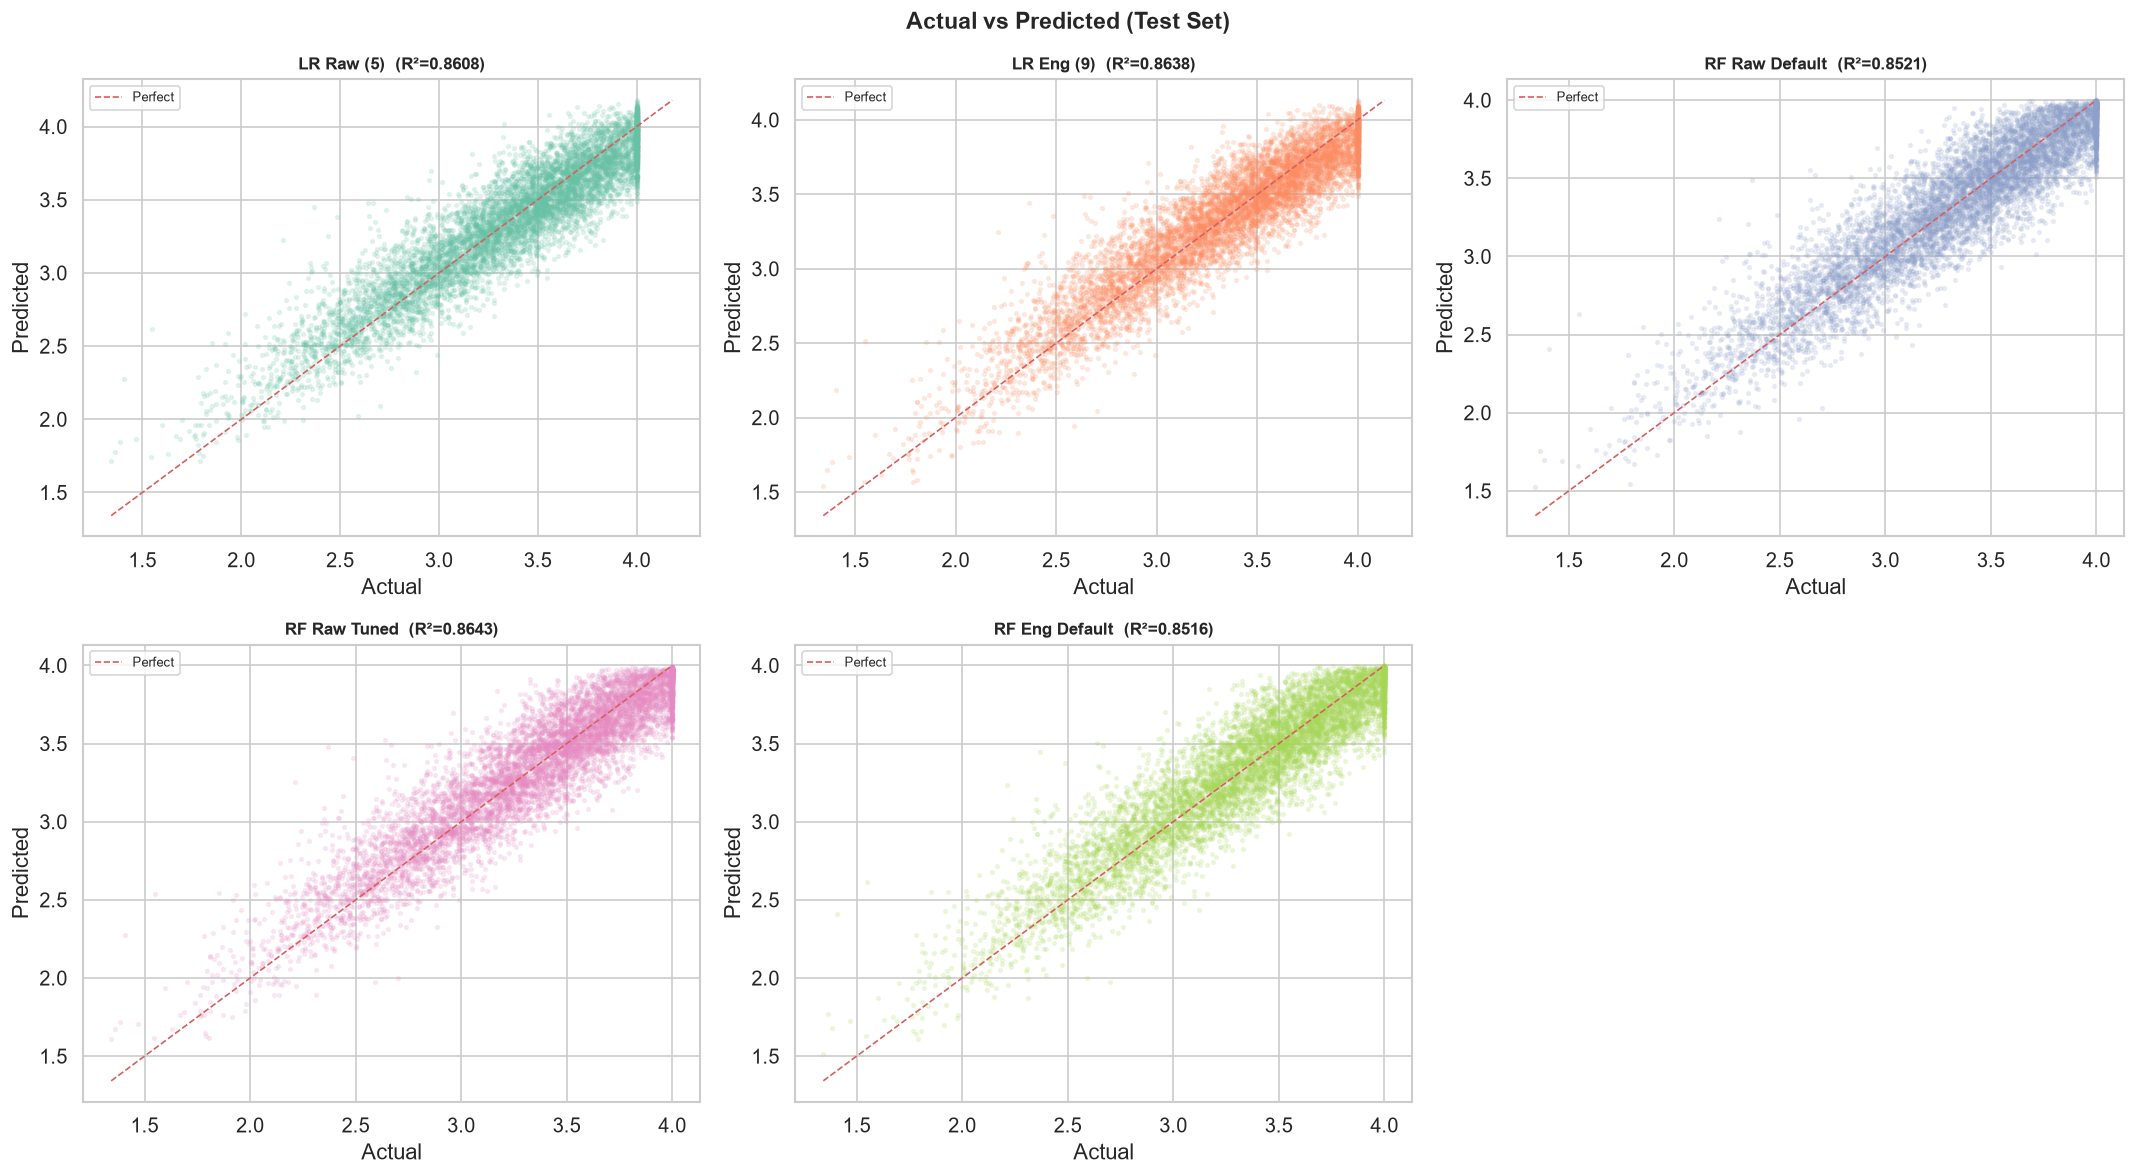

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, res) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    pred_test_vals = res["predictions"]["test"]
    
    ax.scatter(y_test, pred_test_vals, alpha=0.15, s=5, color=colors[idx])
    # Perfect prediction line
    lims = [min(y_test.min(), pred_test_vals.min()),
            max(y_test.max(), pred_test_vals.max())]
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect")
    ax.set_title(f"{name}  (R²={res['test']['R²']:.4f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)

if len(results) < 6:
    for idx in range(len(results), 6):
        axes[idx // 3, idx % 3].set_visible(False)

plt.suptitle("Actual vs Predicted (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 10. Feature Importance

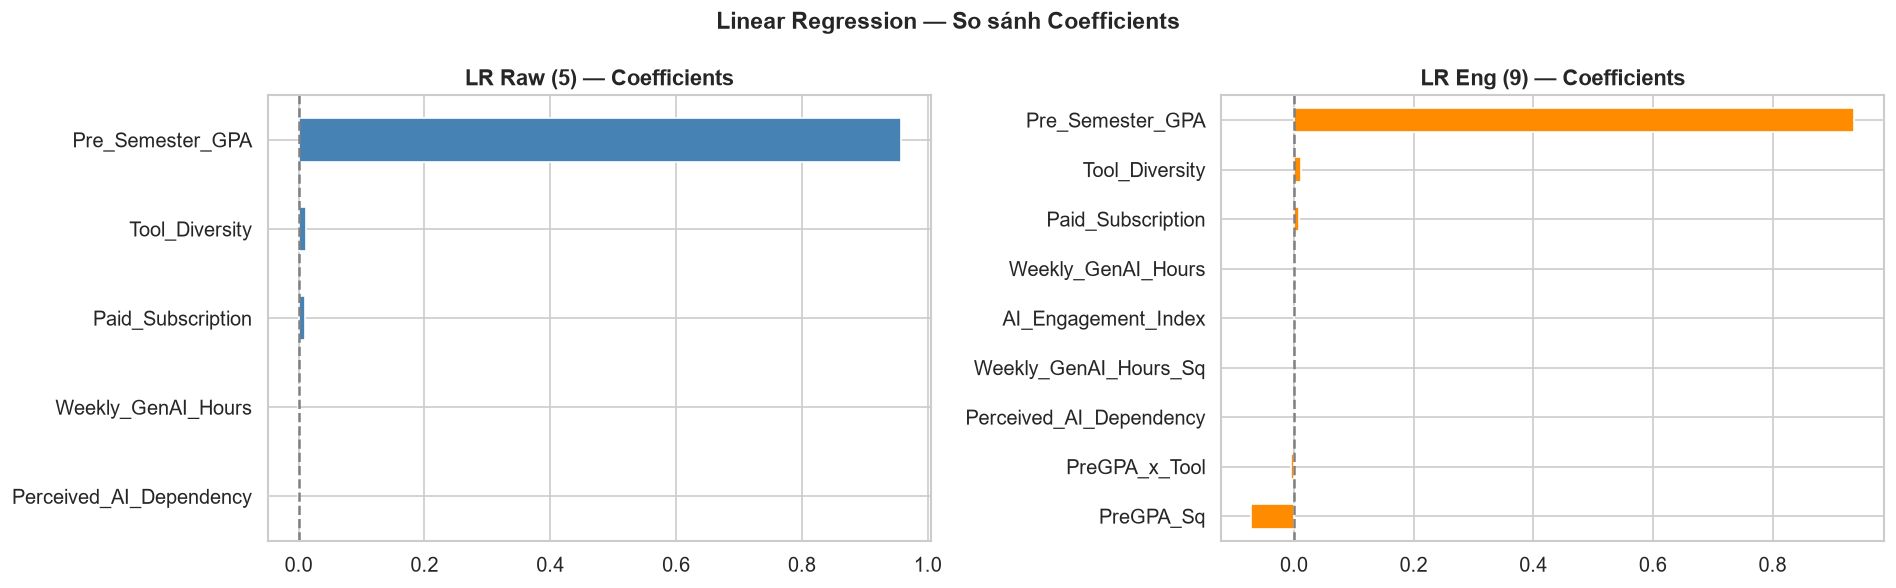

In [17]:
# 10.1 Linear Regression — Coefficient comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LR Raw
coefs_raw = pd.Series(lr_raw.coef_, index=base_features).sort_values()
coefs_raw.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("LR Raw (5) — Coefficients", fontweight="bold")
axes[0].axvline(x=0, color="gray", linestyle="--")

# LR Engineered
coefs_eng = pd.Series(lr_eng.coef_, index=all_features).sort_values()
coefs_eng.plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("LR Eng (9) — Coefficients", fontweight="bold")
axes[1].axvline(x=0, color="gray", linestyle="--")

plt.suptitle("Linear Regression — So sánh Coefficients", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

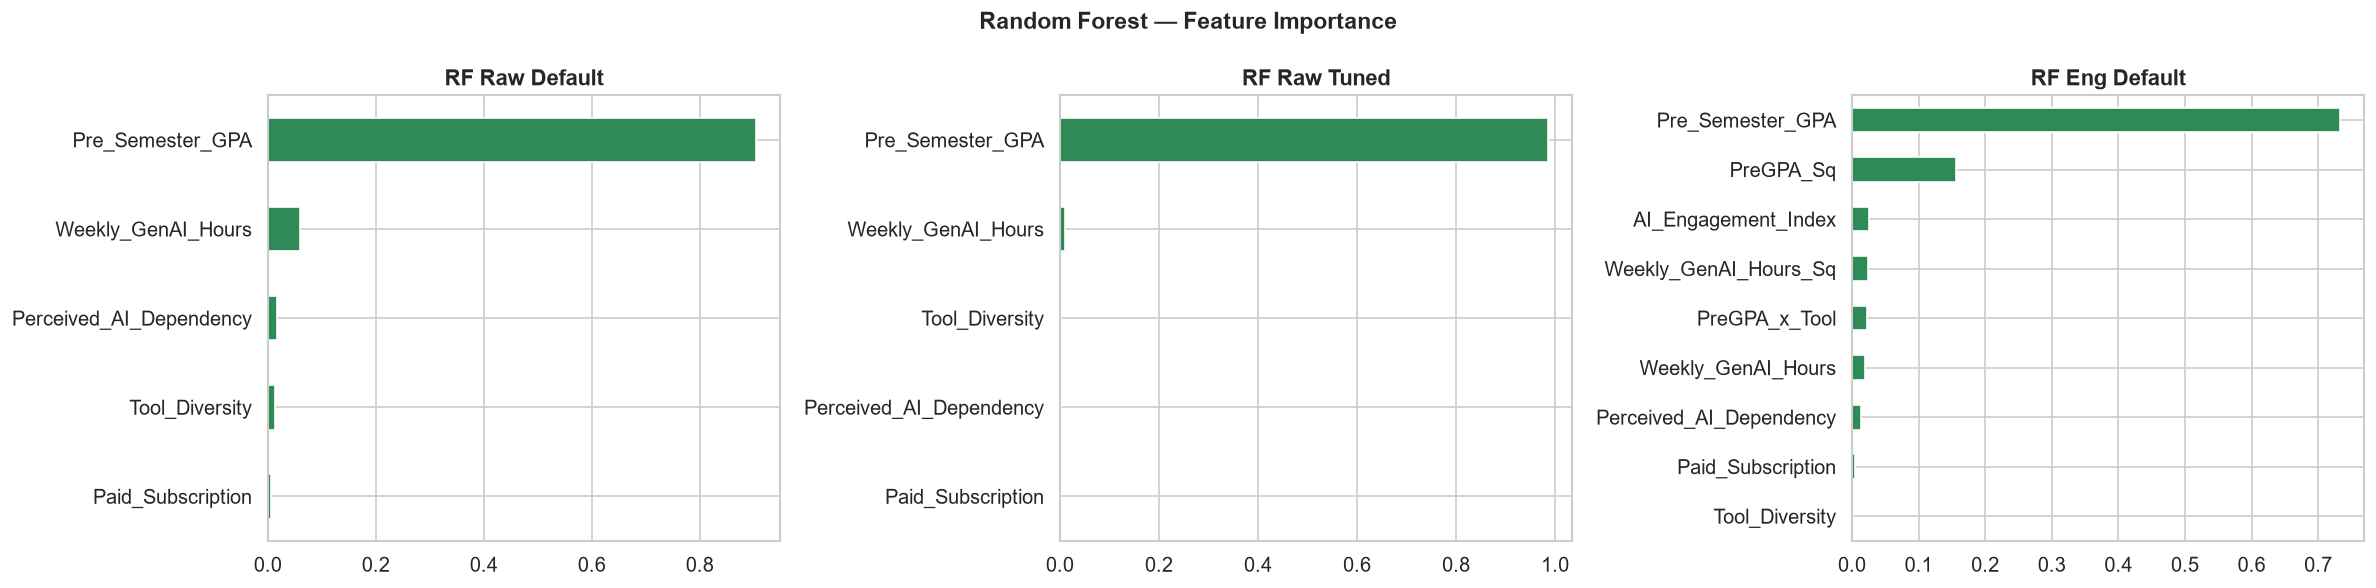

In [18]:
# 10.2 Random Forest — Feature Importance comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Get feature names from preprocessor
raw_feature_names = [f for f in base_features if f not in cfg.binary_feature] + cfg.binary_feature
eng_feature_names = (
    [f for f in base_features if f not in cfg.binary_feature]
    + engineered_only
    + cfg.binary_feature
)

for ax, (name, feature_names) in zip(axes, [
    ("RF Raw Default", raw_feature_names),
    ("RF Raw Tuned", raw_feature_names),
    ("RF Eng Default", eng_feature_names),
]):
    model = results[name]["model"]
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    imp.plot.barh(ax=ax, color="seagreen")
    ax.set_title(f"{name}", fontweight="bold")

plt.suptitle("Random Forest — Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 11. Phân tích: Improvement từ Engineered Features

In [19]:
print("PHÂN TÍCH CẢI THIỆN TỪ ENGINEERED FEATURES")

# Linear Regression improvement
lr_raw_mse = results["LR Raw (5)"]["test"]["MSE"]
lr_eng_mse = results["LR Eng (9)"]["test"]["MSE"]
lr_delta = lr_raw_mse - lr_eng_mse
lr_pct   = lr_delta / lr_raw_mse * 100

print(f"\nLinear Regression:")
print(f"   Raw (5 feat)  Test MSE: {lr_raw_mse:.6f}")
print(f"   Eng (9 feat)  Test MSE: {lr_eng_mse:.6f}")
print(f"   Improvement:           {lr_delta:.6f}  ({lr_pct:+.2f}%)")

lr_raw_r2 = results["LR Raw (5)"]["test"]["R²"]
lr_eng_r2 = results["LR Eng (9)"]["test"]["R²"]
print(f"   Raw R²: {lr_raw_r2:.6f}  →  Eng R²: {lr_eng_r2:.6f}  (Δ = {lr_eng_r2 - lr_raw_r2:+.6f})")

# Random Forest improvement
rf_raw_mse = results["RF Raw Default"]["test"]["MSE"]
rf_eng_mse = results["RF Eng Default"]["test"]["MSE"]
rf_delta = rf_raw_mse - rf_eng_mse
rf_pct   = rf_delta / rf_raw_mse * 100

print(f"\nRandom Forest Default:")
print(f"   Raw (5 feat)  Test MSE: {rf_raw_mse:.6f}")
print(f"   Eng (9 feat)  Test MSE: {rf_eng_mse:.6f}")
print(f"   Improvement:           {rf_delta:.6f}  ({rf_pct:+.2f}%)")

rf_raw_r2 = results["RF Raw Default"]["test"]["R²"]
rf_eng_r2 = results["RF Eng Default"]["test"]["R²"]
print(f"   Raw R²: {rf_raw_r2:.6f}  →  Eng R²: {rf_eng_r2:.6f}  (Δ = {rf_eng_r2 - rf_raw_r2:+.6f})")

# RF Tuned vs RF Default
rf_tuned_mse = results["RF Raw Tuned"]["test"]["MSE"]
rf_t_delta = rf_raw_mse - rf_tuned_mse
rf_t_pct   = rf_t_delta / rf_raw_mse * 100

print(f"\nTuning Effect (RF Raw):")
print(f"   Default Test MSE: {rf_raw_mse:.6f}")
print(f"   Tuned   Test MSE: {rf_tuned_mse:.6f}")
print(f"   Improvement:      {rf_t_delta:.6f}  ({rf_t_pct:+.2f}%)")

PHÂN TÍCH CẢI THIỆN TỪ ENGINEERED FEATURES

Linear Regression:
   Raw (5 feat)  Test MSE: 0.035145
   Eng (9 feat)  Test MSE: 0.034390
   Improvement:           0.000756  (+2.15%)
   Raw R²: 0.860791  →  Eng R²: 0.863784  (Δ = +0.002993)

Random Forest Default:
   Raw (5 feat)  Test MSE: 0.037327
   Eng (9 feat)  Test MSE: 0.037464
   Improvement:           -0.000137  (-0.37%)
   Raw R²: 0.852147  →  Eng R²: 0.851606  (Δ = -0.000542)

Tuning Effect (RF Raw):
   Default Test MSE: 0.037327
   Tuned   Test MSE: 0.034257
   Improvement:      0.003070  (+8.23%)


---
## 13. Heatmap: Tổng quan Metric

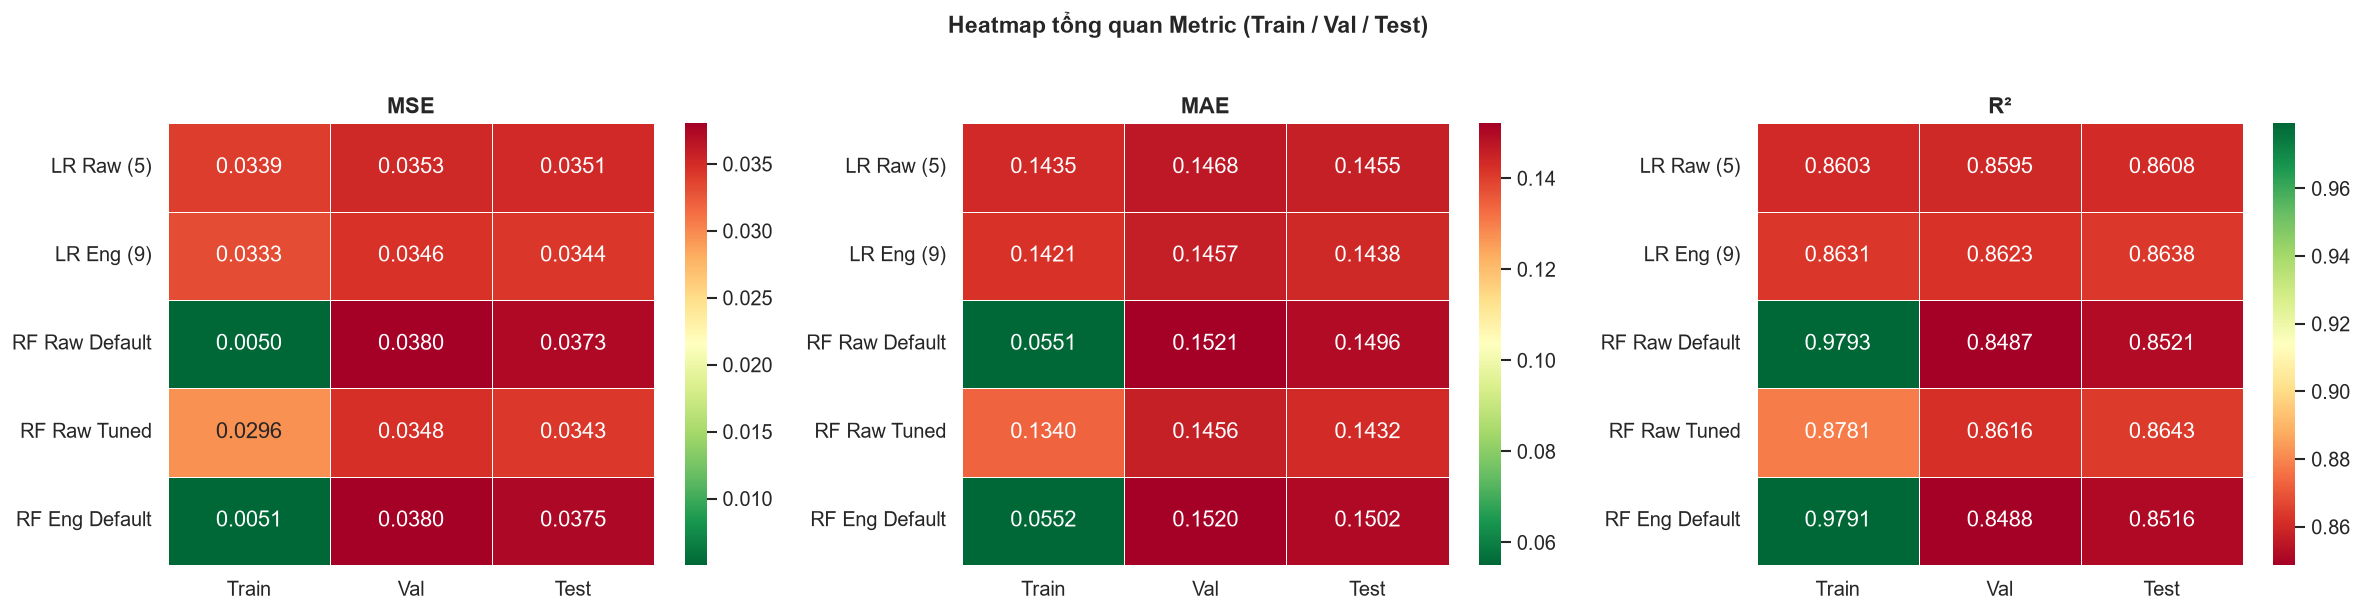

In [20]:
# Create a summary heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

model_names = list(results.keys())
splits = ["train", "val", "test"]

for ax, metric in zip(axes, ["MSE", "MAE", "R²"]):
    data = pd.DataFrame(
        {s.capitalize(): [results[name][s][metric] for name in model_names]
         for s in splits},
        index=model_names,
    )
    cmap = "RdYlGn_r" if metric in ("MSE", "MAE") else "RdYlGn"
    sns.heatmap(data, annot=True, fmt=".4f", cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(f"{metric}", fontsize=13, fontweight="bold")
    ax.set_ylabel("")

plt.suptitle("Heatmap tổng quan Metric (Train / Val / Test)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()